In [ ]:

import os
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

def load_spotify_dataset():
    """
    Завантажує датасет одним із способів:
    1) локальний CSV у папці з ноутбуком;
    2) будь-який CSV у поточній папці;
    3) через kagglehub, якщо він встановлений.
    """
    candidates = [
        "spotify-2023.csv",
        "Spotify-2023.csv",
        "Most Streamed Spotify Songs 2023.csv",
        "most_streamed_spotify_songs_2023.csv"
    ]

    for name in candidates:
        if Path(name).exists():
            print(f"Знайдено локальний файл: {name}")
            return read_csv_safely(name)

    local_csvs = glob.glob("*.csv")
    if local_csvs:
        print(f"Знайдено CSV у поточній папці: {local_csvs[0]}")
        return read_csv_safely(local_csvs[0])

    try:
        import kagglehub
        path = kagglehub.dataset_download("nelgiriyewithana/top-spotify-songs-2023")
        print("Path to dataset files:", path)
        csv_files = glob.glob(os.path.join(path, "*.csv"))
        if not csv_files:
            raise FileNotFoundError("У каталозі датасету не знайдено CSV-файл.")
        print("CSV file:", csv_files[0])
        return read_csv_safely(csv_files[0])
    except ModuleNotFoundError:
        raise ModuleNotFoundError(
            "Не знайдено локальний CSV і не встановлено kagglehub.\n"
            "Або поклади CSV поруч із ноутбуком, або встанови kagglehub."
        )

def read_csv_safely(csv_path):
    encodings = ["utf-8", "latin1", "cp1252"]
    last_error = None
    for enc in encodings:
        try:
            df = pd.read_csv(csv_path, encoding=enc)
            print(f"Файл успішно зчитано з кодуванням: {enc}")
            return df
        except Exception as e:
            last_error = e
    raise last_error

df = load_spotify_dataset()
print("Розмір таблиці:", df.shape)
display(df.head())
print("Колонки:")
print(df.columns.tolist())


Using Colab cache for faster access to the 'top-spotify-songs-2023' dataset.
Path to dataset files: /kaggle/input/top-spotify-songs-2023
CSV file: /kaggle/input/top-spotify-songs-2023/spotify-2023.csv
Файл успішно зчитано з кодуванням: latin1
Розмір таблиці: (953, 24)


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


Колонки:
['track_name', 'artist(s)_name', 'artist_count', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']


In [ ]:

def find_column(possible_names):
    lower_map = {col.lower().strip(): col for col in df.columns}
    for name in possible_names:
        if name.lower().strip() in lower_map:
            return lower_map[name.lower().strip()]
    for col in df.columns:
        c = col.lower().strip()
        for name in possible_names:
            n = name.lower().strip()
            if n in c:
                return col
    return None

track_col = find_column(["track_name", "track name", "song", "song_name", "title"])
artist_col = find_column(["artist(s)_name", "artist_name", "artist", "artists", "artist(s) name"])
streams_col = find_column(["streams", "stream", "spotify_streams"])
released_year_col = find_column(["released_year", "year", "release_year"])
released_month_col = find_column(["released_month", "month", "release_month"])
genre_col = find_column(["genre", "genres"])

print("track_col =", track_col)
print("artist_col =", artist_col)
print("streams_col =", streams_col)
print("released_year_col =", released_year_col)
print("released_month_col =", released_month_col)
print("genre_col =", genre_col)

if track_col is None or artist_col is None or streams_col is None:
    raise ValueError("Не вдалося знайти одну з основних колонок: track / artist / streams")


track_col = track_name
artist_col = artist(s)_name
streams_col = streams
released_year_col = released_year
released_month_col = released_month
genre_col = None


In [ ]:

work_df = df.copy()

work_df[streams_col] = (
    work_df[streams_col]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)
work_df[streams_col] = pd.to_numeric(work_df[streams_col], errors="coerce")

work_df = work_df.dropna(subset=[streams_col])

print("Після очищення:", work_df.shape)
display(work_df[[track_col, artist_col, streams_col]].head())


Після очищення: (952, 24)


,track_name,artist(s)_name,streams
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",141381703.0
1,LALA,Myke Towers,133716286.0
2,vampire,Olivia Rodrigo,140003974.0
3,Cruel Summer,Taylor Swift,800840817.0
4,WHERE SHE GOES,Bad Bunny,303236322.0


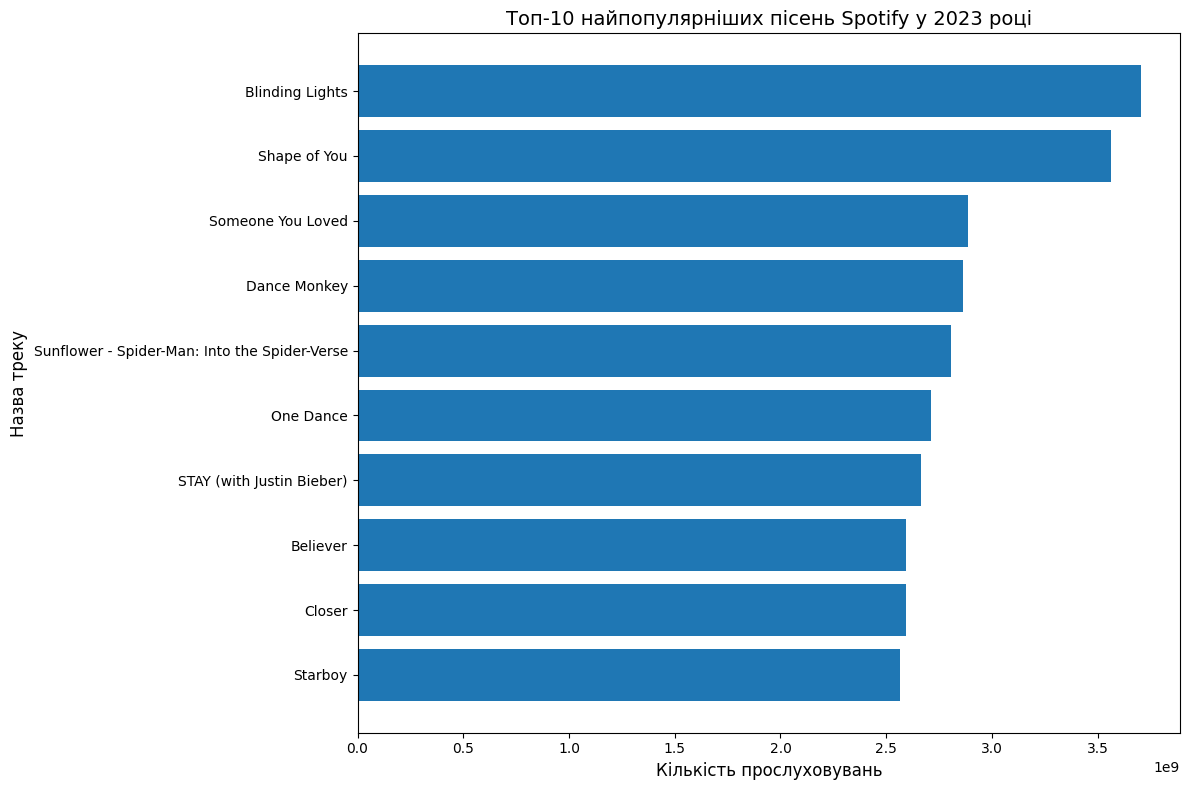

,track_name,artist(s)_name,streams
48,Starboy,"The Weeknd, Daft Punk",2.565530e+09
725,Closer,"The Chainsmokers, Halsey",2.591224e+09
140,Believer,Imagine Dragons,2.594040e+09
84,STAY (with Justin Bieber),"Justin Bieber, The Kid Laroi",2.665344e+09
162,One Dance,"Drake, WizKid, Kyla",2.713922e+09
41,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee",2.808097e+09
620,Dance Monkey,Tones and I,2.864792e+09
86,Someone You Loved,Lewis Capaldi,2.887242e+09
179,Shape of You,Ed Sheeran,3.562544e+09
55,Blinding Lights,The Weeknd,3.703895e+09


In [ ]:

top_10_tracks = work_df.nlargest(10, streams_col)[[track_col, artist_col, streams_col]].copy()
top_10_tracks = top_10_tracks.sort_values(by=streams_col, ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(top_10_tracks[track_col], top_10_tracks[streams_col])
plt.title("Топ-10 найпопулярніших пісень Spotify у 2023 році")
plt.xlabel("Кількість прослуховувань")
plt.ylabel("Назва треку")
plt.tight_layout()
plt.show()

display(top_10_tracks)


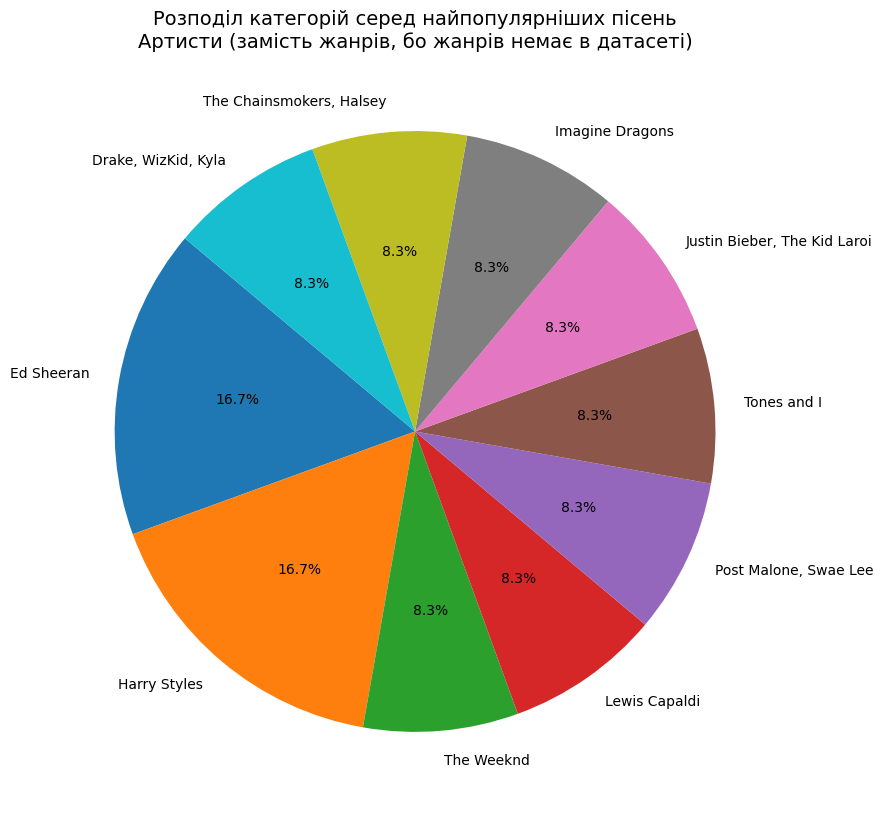

,count
artist(s)_name,
Ed Sheeran,2
Harry Styles,2
The Weeknd,1
Lewis Capaldi,1
"Post Malone, Swae Lee",1
Tones and I,1
"Justin Bieber, The Kid Laroi",1
Imagine Dragons,1
"The Chainsmokers, Halsey",1


In [ ]:

top_popular = work_df.nlargest(20, streams_col).copy()

if genre_col is not None:
    genre_data = top_popular[genre_col].fillna("Unknown").value_counts()
    label_name = "Жанри"
else:
    genre_data = top_popular[artist_col].fillna("Unknown").value_counts().head(10)
    label_name = "Артисти (замість жанрів, бо жанрів немає в датасеті)"

plt.figure(figsize=(9, 9))
plt.pie(genre_data.values, labels=genre_data.index, autopct='%1.1f%%', startangle=140)
plt.title(f"Розподіл категорій серед найпопулярніших пісень\n{label_name}")
plt.tight_layout()
plt.show()

display(genre_data)


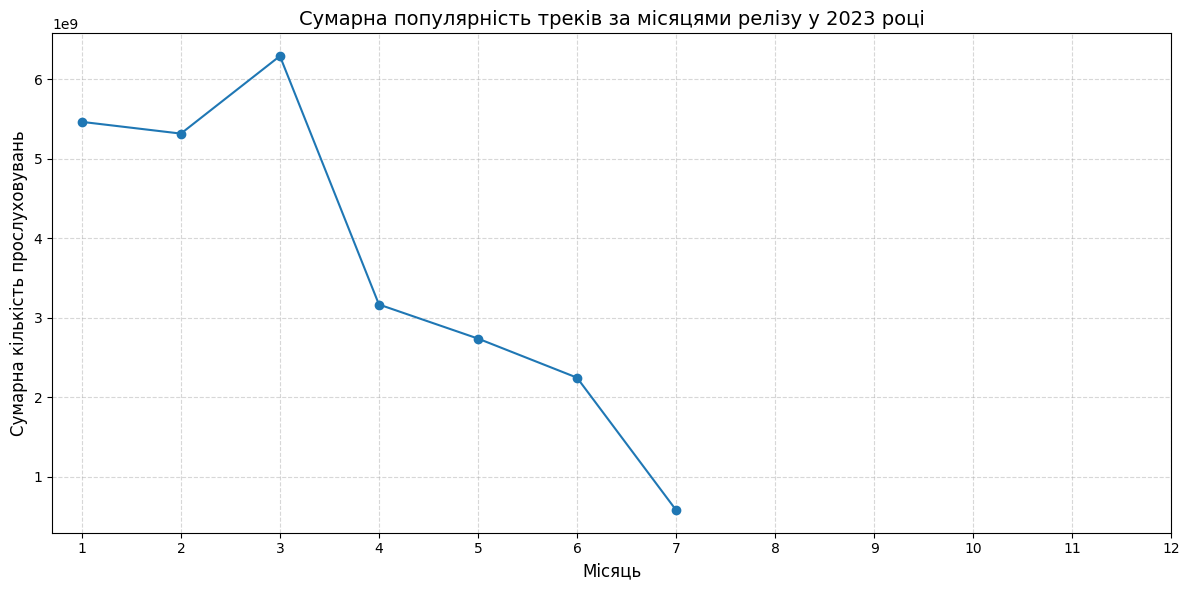

,streams
released_month,
1,5.465074e+09
2,5.317407e+09
3,6.293414e+09
4,3.166914e+09
5,2.738202e+09
6,2.246408e+09
7,5.810653e+08


In [ ]:

if released_year_col is not None and released_month_col is not None:
    temp = work_df.copy()
    temp[released_year_col] = pd.to_numeric(temp[released_year_col], errors="coerce")
    temp[released_month_col] = pd.to_numeric(temp[released_month_col], errors="coerce")

    monthly_data = (
        temp[temp[released_year_col] == 2023]
        .groupby(released_month_col)[streams_col]
        .sum()
        .sort_index()
    )

    plt.figure(figsize=(12, 6))
    plt.plot(monthly_data.index, monthly_data.values, marker='o')
    plt.title("Сумарна популярність треків за місяцями релізу у 2023 році")
    plt.xlabel("Місяць")
    plt.ylabel("Сумарна кількість прослуховувань")
    plt.xticks(range(1, 13))
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    display(monthly_data)
else:
    print("У датасеті немає колонок released_year / released_month, тому це завдання пропущено.")


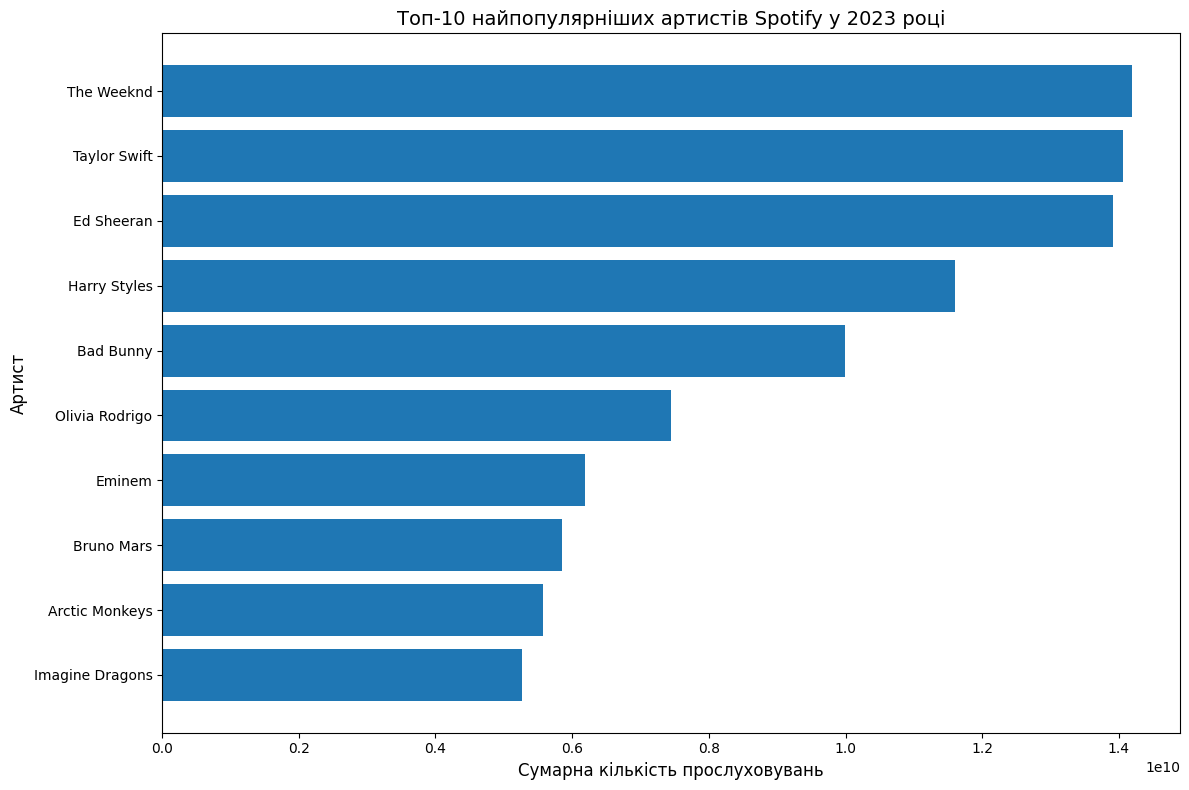

,streams
artist(s)_name,
Imagine Dragons,5.272485e+09
Arctic Monkeys,5.569807e+09
Bruno Mars,5.846921e+09
Eminem,6.183806e+09
Olivia Rodrigo,7.442149e+09
Bad Bunny,9.997800e+09
Harry Styles,1.160865e+10
Ed Sheeran,1.390895e+10
Taylor Swift,1.405366e+10


In [ ]:

artist_rating = (
    work_df.groupby(artist_col)[streams_col]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 8))
plt.barh(artist_rating.index, artist_rating.values)
plt.title("Топ-10 найпопулярніших артистів Spotify у 2023 році")
plt.xlabel("Сумарна кількість прослуховувань")
plt.ylabel("Артист")
plt.tight_layout()
plt.show()

display(artist_rating)


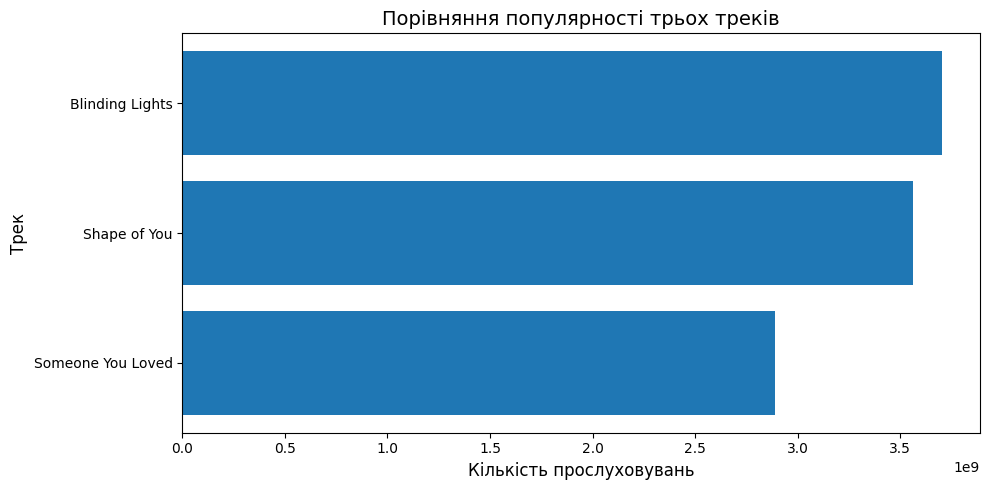

,track_name,artist(s)_name,streams
86,Someone You Loved,Lewis Capaldi,2.887242e+09
179,Shape of You,Ed Sheeran,3.562544e+09
55,Blinding Lights,The Weeknd,3.703895e+09


In [ ]:

top_3_tracks = work_df.nlargest(3, streams_col)[[track_col, artist_col, streams_col]].copy()
top_3_tracks = top_3_tracks.sort_values(by=streams_col, ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(top_3_tracks[track_col], top_3_tracks[streams_col])
plt.title("Порівняння популярності трьох треків")
plt.xlabel("Кількість прослуховувань")
plt.ylabel("Трек")
plt.tight_layout()
plt.show()

display(top_3_tracks)


## Висновок

У ході лабораторної роботи було побудовано кілька типів візуалізацій за допомогою бібліотеки **Matplotlib** для аналізу датасету Spotify 2023.  
Було визначено найпопулярніші пісні та артистів за кількістю прослуховувань, виконано порівняння окремих треків, а також побудовано діаграму розподілу категорій серед популярних композицій.  

Під час виконання роботи виявлено, що структура датасету може відрізнятися залежно від версії файлу: зокрема, іноді відсутня колонка жанрів або повна часова динаміка одного треку. Тому в ноутбуці передбачено гнучке визначення назв колонок і безпечне зчитування CSV з різними кодуваннями.  

Отже, Matplotlib є зручним інструментом для візуального аналізу музичних даних, а побудовані графіки дають змогу наочно оцінити популярність треків і артистів у Spotify за 2023 рік.
